In [6]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import coo_matrix, csc_matrix
from scipy.sparse.linalg import lsqr



<div style="color: green; font-weight: bold">The import part is as needed</div>

In [7]:
def construct_X(M, alphas, Np=None):
    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))

    if Np % 2 == 0:
        Np += 1

    alphas = np.asarray(alphas, dtype=np.float64)
    No = len(alphas)
    D = M * M
    N = No * Np


    ja, jb = np.mgrid[0:M, 0:M]


    ja = ja.T
    jb = jb.T

    a0 = -(M - 1) / 2.0
    b0 = -(M - 1) / 2.0

    a_coords = a0 + ja
    b_coords = b0 + jb

    C = np.vstack((a_coords.ravel(order="C"), b_coords.ravel(order="C")))

    s0 = (Np - 1) / 2.0
    pixel_indices = np.arange(D, dtype=np.int32)

    all_i = []
    all_j = []
    all_w = []

    for io, alpha_deg in enumerate(alphas):
        alpha = np.deg2rad(alpha_deg)


        n = np.array([np.cos(alpha), np.sin(alpha)], dtype=np.float64)

        p = n @ C + s0

        left_bin = np.floor(p).astype(np.int32)
        frac = p - left_bin
        right_bin = left_bin + 1

        w_left = 1.0 - frac
        w_right = frac

        valid_left = (left_bin >= 0) & (left_bin < Np) & (w_left > 1e-12)
        valid_right = (right_bin >= 0) & (right_bin < Np) & (w_right > 1e-12)

        i_left = left_bin[valid_left] + io * Np
        j_left = pixel_indices[valid_left]
        weights_left = w_left[valid_left]

        i_right = right_bin[valid_right] + io * Np
        j_right = pixel_indices[valid_right]
        weights_right = w_right[valid_right]

        all_i.append(i_left)
        all_i.append(i_right)
        all_j.append(j_left)
        all_j.append(j_right)
        all_w.append(weights_left)
        all_w.append(weights_right)

    i_indices = np.concatenate(all_i).astype(np.int32)
    j_indices = np.concatenate(all_j).astype(np.int32)
    weights = np.concatenate(all_w).astype(np.float32)

    X = coo_matrix((weights, (i_indices, j_indices)), shape=(N, D), dtype=np.float32)

    return X.tocsc()

<div style="color: green; font-weight: bold">They have used vectorized sparse matrix creation as well. And this should have a better time performance; having only 1 for loop</div>

In [8]:
def report_sparsity(X, name="X"):
    total_entries = X.shape[0] * X.shape[1]
    nnz = X.nnz
    sparsity = 1.0 - nnz / total_entries

    print(f"{name}.shape      = {X.shape}")
    print(f"{name}.nnz        = {nnz}")
    print(f"{name} sparsity   = {sparsity:.8f}")
    print(f"{name} zero share = {100 * sparsity:.4f}%")

    return nnz, sparsity


def plot_matrix(X, title="Projection matrix X"):
    plt.figure(figsize=(10, 6))
    plt.imshow(X.toarray(), cmap="gray", aspect="auto")
    plt.title(title)
    plt.xlabel("pixel index j")
    plt.ylabel("measurement index i")
    plt.tight_layout()
    plt.show()


def plot_sinogram(y, Np, title="Sinogram"):
    No = len(y) // Np
    s = y.reshape((No, Np))
    plt.figure(figsize=(8, 6))
    plt.imshow(s, cmap="gray", aspect="auto")
    plt.title(title)
    plt.xlabel("sensor bin")
    plt.ylabel("angle index")
    plt.tight_layout()
    plt.show()


def plot_tomogram(mu, title="Tomogram"):
    plt.figure(figsize=(6, 6))
    plt.imshow(mu, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

<div style="color: green; font-weight: bold">They have implemented all the functions needed later in one place; which i find better and more clear code style. The only difference is that in the solution for sparsity there is another formula mentioned and used than what they are using; but all in all it works well</div>

In [9]:
def load_experiment_data(base_path, M):
    if M == 77:
        alphas_file = os.path.join(base_path, "alphas_77.npy")
        y_file = os.path.join(base_path, "y_77.npy")
        Np = 109
    elif M == 195:
        alphas_file = os.path.join(base_path, "alphas_195.npy")
        y_file = os.path.join(base_path, "y_195.npy")
        Np = 275
    else:
        raise ValueError("Supported values are M=77 and M=195.")

    alphas = np.load(alphas_file)
    y = np.load(y_file)

    return alphas, y, Np

<div style="color: green; font-weight: bold">They have implemented both larg and small image experiment in one function</div>

In [10]:
def reconstruct_tomogram(X, y, M, atol=1e-5, btol=1e-5, iter_lim=None):
    result = lsqr(X, y, atol=atol, btol=btol, iter_lim=iter_lim)

    beta = result[0]
    istop = result[1]
    itn = result[2]
    r1norm = result[3]
    r2norm = result[4]

    mu = beta.reshape((M, M), order="C")

    print("LSQR finished:")
    print(f"  istop  = {istop}")
    print(f"  itn    = {itn}")
    print(f"  r1norm = {r1norm:.6e}")
    print(f"  r2norm = {r2norm:.6e}")

    return beta, mu, result


<div style="color: green; font-weight: bold">Writing a function for lsqr (or the equation system solving)</div>

X_example.shape      = (45, 100)
X_example.nnz        = 600
X_example sparsity   = 0.86666667
X_example zero share = 86.6667%


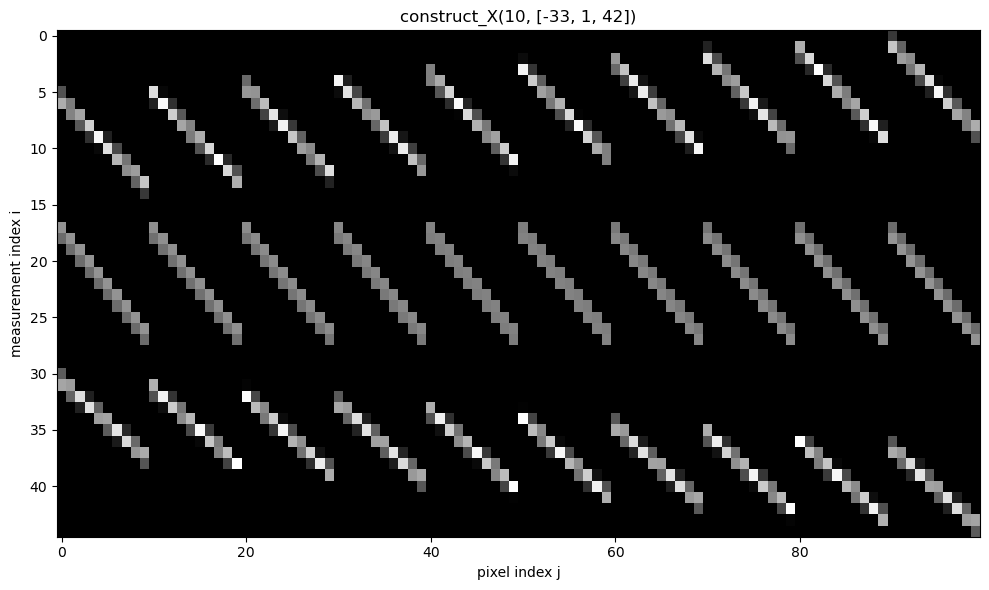

In [11]:
X_example = construct_X(10, [-33, 1, 42])
report_sparsity(X_example, "X_example")
plot_matrix(X_example, title="construct_X(10, [-33, 1, 42])")

<div style="color: green; font-weight: bold">Their implementation is as it was supposed to be</div>

Plotting has inverted x orientation compared to the example but is the same apart from that

In [12]:
base_path = "hs_tomography"

In [13]:
M = 77
alphas, y, Np = load_experiment_data(base_path, M)

print("Loaded small dataset:")
print("M =", M)
print("Np =", Np)
print("number of angles =", len(alphas))
print("len(y) =", len(y))

Loaded small dataset:
M = 77
Np = 109
number of angles = 90
len(y) = 9810


In [14]:
t0 = time.time()
X = construct_X(M, alphas, Np)
t1 = time.time()

print(f"Construction time: {t1 - t0:.2f} s")
report_sparsity(X, "X_77")

Construction time: 0.03 s
X_77.shape      = (9810, 5929)
X_77.nnz        = 1066978
X_77 sparsity   = 0.98165554
X_77 zero share = 98.1656%


(1066978, 0.98165553683247)

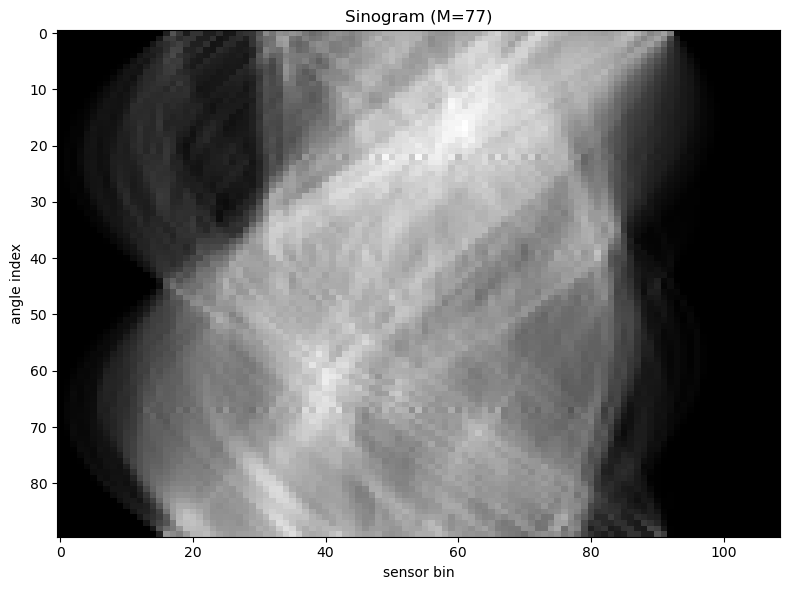

In [15]:
plot_sinogram(y, Np, title="Sinogram (M=77)")

<div style="color: green; font-weight: bold">So they have implemented Sinogram with y, but the thing is that it differs from Solution</div>

In [16]:
beta, mu, result = reconstruct_tomogram(X, y, M, atol=1e-5, btol=1e-5)

LSQR finished:
  istop  = 1
  itn    = 276
  r1norm = 6.187553e+01
  r2norm = 6.187553e+01


In [17]:
np.save(os.path.join(base_path, "reconstruction_77.npy"), mu)

In [18]:
M = 195
alphas, y, Np = load_experiment_data(base_path, M)

print("Loaded large dataset:")
print("M =", M)
print("Np =", Np)
print("number of angles =", len(alphas))
print("len(y) =", len(y))

Loaded large dataset:
M = 195
Np = 275
number of angles = 179
len(y) = 49225


In [19]:
t0 = time.time()
X = construct_X(M, alphas, Np)
t1 = time.time()

print(f"Construction time: {t1 - t0:.2f} s")
report_sparsity(X, "X_195")

Construction time: 0.26 s
X_195.shape      = (49225, 38025)
X_195.nnz        = 13535931
X_195 sparsity   = 0.99276842
X_195 zero share = 99.2768%


(13535931, 0.9927684201774447)

In [20]:
t0 = time.time()
X = construct_X(M, alphas, Np)
t1 = time.time()

print(f"Construction time: {t1 - t0:.2f} s")
report_sparsity(X, "X_195")

Construction time: 0.18 s
X_195.shape      = (49225, 38025)
X_195.nnz        = 13535931
X_195 sparsity   = 0.99276842
X_195 zero share = 99.2768%


(13535931, 0.9927684201774447)

In [21]:
beta, mu, result = reconstruct_tomogram(X, y, M, atol=1e-5, btol=1e-5)

LSQR finished:
  istop  = 1
  itn    = 152
  r1norm = 2.952363e+02
  r2norm = 2.952363e+02


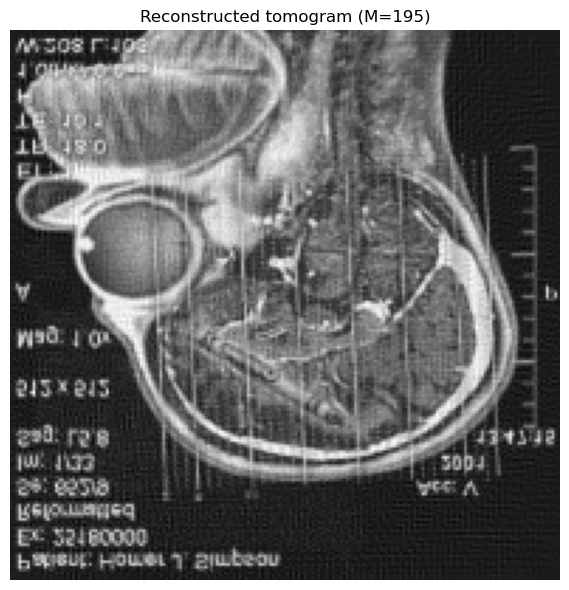

In [22]:
plot_tomogram(mu, title="Reconstructed tomogram (M=195)")

In [23]:
np.save(os.path.join(base_path, "reconstruction_195.npy"), mu)

One can see a pen in his head, which is a relativly unphisiological condition and would probably not just cause a headache...

<div style="color: green; font-weight: bold">They have constructed the larger image and could have recognized the odd object in the brain picture so it is well implemented.</div>

In [27]:
def angle_subsets(alphas, steps=(1, 2, 3, 4, 5, 6, 8, 10)):
    subsets = []
    for step in steps:
        sub = alphas[::step]
        if len(sub) >= 2:
            subsets.append((step, sub))
    return subsets


def run_sparse_projection_experiment(base_path, M, atol=1e-5, btol=1e-5, iter_lim=None,
                                     steps=(1, 2, 3, 4, 5, 6, 8, 10),
                                     cmap="gray", figsize_per_row=(4, 4)):

    alphas, y, Np = load_experiment_data(base_path, M)

    X_full = construct_X(M, alphas, Np)
    beta_full, mu_full, result_full = reconstruct_tomogram(
        X_full, y, M, atol=atol, btol=btol, iter_lim=iter_lim
    )

    subsets = angle_subsets(alphas, steps=steps)

    recons = []
    metrics = []

    for step, sub_alphas in subsets:



        selected_angle_ids = np.arange(len(alphas))[::step]
        selected_rows = np.concatenate([
            np.arange(i * Np, (i + 1) * Np) for i in selected_angle_ids
        ])
        y_sub = y[selected_rows]


        X_sub = construct_X(M, sub_alphas, Np)
        beta_sub, mu_sub, result_sub = reconstruct_tomogram(
            X_sub, y_sub, M, atol=atol, btol=btol, iter_lim=iter_lim
        )

        mse = np.mean((mu_sub - mu_full) ** 2)
        rel_err = np.linalg.norm(mu_sub - mu_full) / np.linalg.norm(mu_full)

        recons.append({
            "step": step,
            "num_angles": len(sub_alphas),
            "alphas": sub_alphas,
            "mu": mu_sub,
            "beta": beta_sub,
            "result": result_sub
        })

        metrics.append({
            "step": step,
            "num_angles": len(sub_alphas),
            "mse": mse,
            "relative_error": rel_err
        })


    print(f"{'step':>6} {'num_angles':>12} {'mse':>14} {'relative_error':>18}")
    for m in metrics:
        print(f"{m['step']:>6} {m['num_angles']:>12} {m['mse']:>14.6e} {m['relative_error']:>18.6e}")


    n = len(recons) + 1
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_per_row[0], nrows * figsize_per_row[1]))
    axes = np.array(axes).ravel()


    ax = axes[0]
    im = ax.imshow(mu_full, cmap=cmap)
    ax.set_title(f"Full\n{len(alphas)} projections")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


    for k, rec in enumerate(recons, start=1):
        ax = axes[k]
        im = ax.imshow(rec["mu"], cmap=cmap)
        ax.set_title(f"step={rec['step']}\n{rec['num_angles']} projections")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for k in range(len(recons) + 1, len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()


    n = len(recons)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_per_row[0], nrows * figsize_per_row[1]))
    axes = np.array(axes).ravel()

    for k, rec in enumerate(recons):
        diff = rec["mu"] - mu_full
        ax = axes[k]
        im = ax.imshow(diff, cmap="bwr")
        ax.set_title(f"Difference\n{rec['num_angles']} projections")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for k in range(len(recons), len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()


    num_angles = [m["num_angles"] for m in metrics]
    mse_vals = [m["mse"] for m in metrics]
    rel_vals = [m["relative_error"] for m in metrics]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(num_angles, mse_vals, "o-")
    ax[0].set_xlabel("Number of projections")
    ax[0].set_ylabel("MSE vs full reconstruction")
    ax[0].set_title("MSE vs projections")
    ax[0].grid(True)

    ax[1].plot(num_angles, rel_vals, "o-")
    ax[1].set_xlabel("Number of projections")
    ax[1].set_ylabel("Relative error vs full reconstruction")
    ax[1].set_title("Relative error vs projections")
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    return {
        "alphas_full": alphas,
        "y_full": y,
        "Np": Np,
        "mu_full": mu_full,
        "beta_full": beta_full,
        "result_full": result_full,
        "reconstructions": recons,
        "metrics": metrics
    }

In [26]:
M = 77

alphas, y, Np = load_experiment_data(base_path, M)


X_full = construct_X(M, alphas, Np)
beta_full, mu_full, result_full = reconstruct_tomogram(X_full, y, M)


step = 4
idx = np.arange(len(alphas))[::step]
alphas_sparse = alphas[idx]


rows = np.concatenate([np.arange(i * Np, (i + 1) * Np) for i in idx])
y_sparse = y[rows]


X_sparse = construct_X(M, alphas_sparse, Np)
beta_sparse, mu_sparse, result_sparse = reconstruct_tomogram(X_sparse, y_sparse, M)

print("full angles:", len(alphas))
print("sparse angles:", len(alphas_sparse))

LSQR finished:
  istop  = 1
  itn    = 276
  r1norm = 6.187553e+01
  r2norm = 6.187553e+01
LSQR finished:
  istop  = 1
  itn    = 185
  r1norm = 2.589504e+01
  r2norm = 2.589504e+01
full angles: 90
sparse angles: 23


<div style="color: green; font-weight: bold">Their projection angles differ because they are random and thats ok. The thing is that they have shown the difference between sparse angles and angles</div>

In [28]:
mse = np.mean((mu_sparse - mu_full) ** 2)
rel_err = np.linalg.norm(mu_sparse - mu_full) / np.linalg.norm(mu_full)

print("MSE:", mse)
print("relative error:", rel_err)

MSE: 935.5007713344274
relative error: 0.28901662321285293


<div style="color: green; font-weight: bold">Here they used mean squared error which was not wanted and they could have just used absolute difference like (abs(mu_sparse - mu_full)).</div>

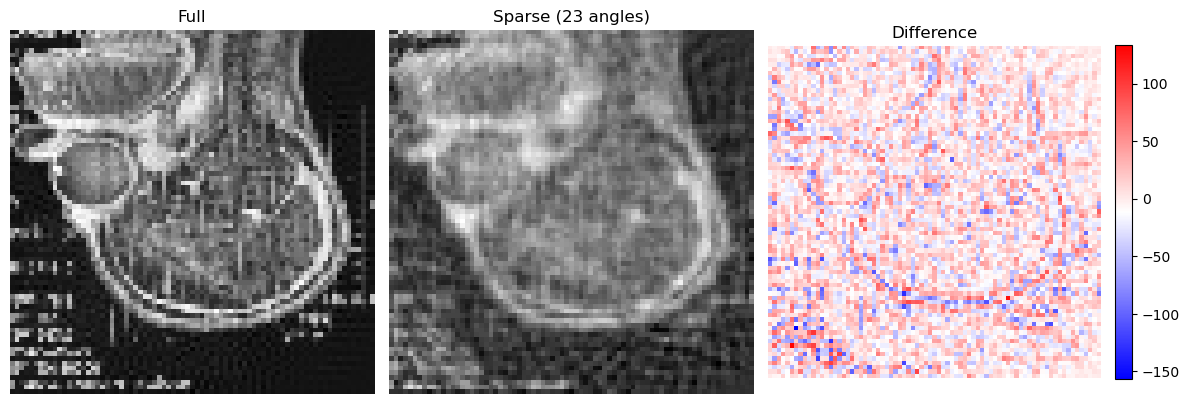

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(mu_full, cmap="gray")
ax[0].set_title("Full")
ax[0].axis("off")

ax[1].imshow(mu_sparse, cmap="gray")
ax[1].set_title(f"Sparse ({len(alphas_sparse)} angles)")
ax[1].axis("off")

im = ax[2].imshow(mu_sparse - mu_full, cmap="bwr")
ax[2].set_title("Difference")
ax[2].axis("off")
plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

<div style="color: green; font-weight: bold">They should have shown picture from the specified angels they used in the previous cells, that way we could have recognized which one (how much angles needed to have a recognizable image) was more recognizable</div>

With 23 angles we can see the physical cause of the headache. With 90 angles we can also identify it. As identification is necessary for good measures, we would recommend roughly 90 angles.